In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import itertools

In [2]:
#custom 4-bit quantization transform function for the MNIST images
class FourBitQuantize:
    def __call__(self, image):
        #quantize the image to 4-bit precision
        quantized_image = torch.floor(image * 15.0) / 15.0

        return quantized_image

In [3]:
#custom 1-bit quantization transform function for the MNIST images
class OneBitQuantize:
    def __call__(self, image):
        #quantize the image to 2-bit precision(round to nearest integer 0 or 1)
        quantized_image = torch.round(image)

        return quantized_image

In [4]:
#Loads the MNIST dataset, downsamples the images to 14x14
transform = transforms.Compose([
    transforms.Resize((14, 14)), #resizes to 14x14
    transforms.ToTensor(), #converts the data to tensors between [0, 1]
    OneBitQuantize(), #quantizes images to 1 bit, essentially converting to binary
    #transforms.Lambda(lambda x: (x > 0.5).float())#convert to binary
])

#Load MNIST dataset and apply transformations
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 55.3MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 2.60MB/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 8.36MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [5]:
labels_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}

#Display a batch of images
def show_images(train_dataset, cols, rows):
  figure = plt.figure(figsize=(8, 8))

  for i in range(1, cols * rows + 1):
      sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
      img, label = train_dataset[sample_idx]
      figure.add_subplot(rows, cols, i)
      plt.title(labels_map[label])
      plt.axis("off")
      plt.imshow(img.squeeze(), cmap="gray")

  plt.show()

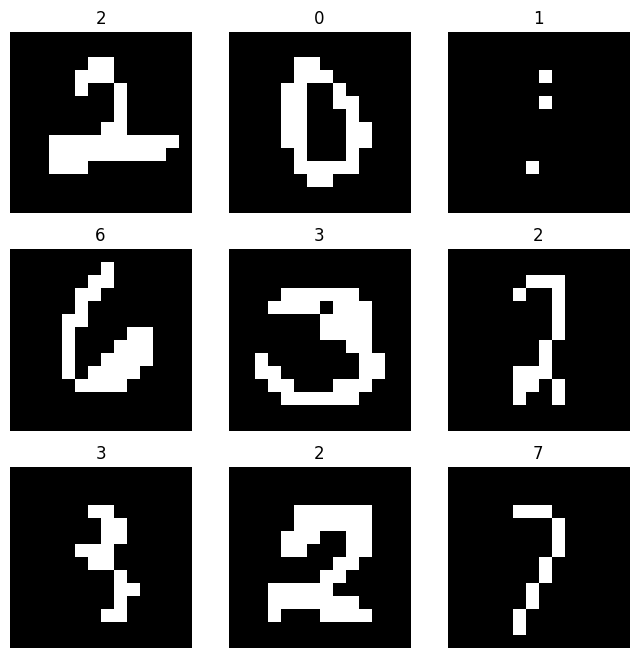

In [6]:
show_images(train_dataset, 3, 3)

In [7]:
activation_quantizer = torch.ao.quantization.FakeQuantize(
    observer=torch.quantization.MinMaxObserver,
    quant_min=0,
    quant_max=1,
    dtype=torch.quint8,
    qscheme=torch.per_tensor_affine
)

In [8]:
weight_quantizer = torch.ao.quantization.FakeQuantize(
    observer=torch.quantization.MinMaxObserver,
    quant_min=0,
    quant_max=255,
    dtype=torch.quint8,
    qscheme=torch.per_tensor_affine
)

step 4 (activation should be 8-bit, weight should be 8-bit)



In [30]:
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

    #quantize weights to 4-bit
    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)

    x = torch.round(torch.clamp(x, 0, 1)) #quantize relu activations to 1 bit(first ensuring all values are between 0 and 1)

    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15  #ensure weights are still quantized to 4 bits

    return x

#average pooling to downsize the image from 14x14 to 7x7
class AvgPoolLayer(nn.Module):
  def __init__(self):
    super(AvgPoolLayer, self).__init__()
    self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    x = self.pool(x)
    x = torch.round(x * 255) / 255 #quantize average pooling to 8 bit(0, 255)
    return x



#This sublayer is implemented by CustomLayer1. It takes a single feature-map-pair of 98 elements and uses two learnable weight-matrices to simulate negative weights.
class SubLayer1(nn.Module):
  def __init__(self):
    super(SubLayer1, self).__init__()

    #create 2 98x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.abs(torch.randn(98, 32))) #torch.abs ensures there aren't negative weight values(chip constraint)
    self.weightb = nn.Parameter(torch.abs(torch.randn(98, 32)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #quantize weights to 8 bit
    #self.weighta = nn.Parameter(torch.round(self.weighta * 256) / 256)
    #self.weightb = nn.Parameter(torch.round(self.weighta * 256) / 256)

  def forward(self, x): #size of x is [64, 98] (batch size, 98 pixels from 2 7x7 feature maps)
    #self.weighta = nn.Parameter(weight_quantizer(self.weighta))
    #self.weightb = nn.Parameter(weight_quantizer(self.weightb))

    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias #output size is [64, 32]

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #quantize the sigmoid activations to 8 bits
    out = activation_quantizer(out)

    return out

#this layer follows the flatten layer of the neural network and simulates 2 chip cores. It recieves a tensor containing all possible pairs of feature maps and the pair's data(98 pixels) and sends each pair to a sublayer1
class CustomLayer1(nn.Module):
  def __init__(self):
    super(CustomLayer1, self).__init__()

    #create 15 sublayers
    self.subLayer1_0 = SubLayer1()
    self.subLayer1_1 = SubLayer1()
    self.subLayer1_2 = SubLayer1()
    self.subLayer1_3 = SubLayer1()
    self.subLayer1_4 = SubLayer1()
    self.subLayer1_5 = SubLayer1()
    self.subLayer1_6 = SubLayer1()
    self.subLayer1_7 = SubLayer1()
    self.subLayer1_8 = SubLayer1()
    self.subLayer1_9 = SubLayer1()
    self.subLayer1_10 = SubLayer1()
    self.subLayer1_11 = SubLayer1()
    self.subLayer1_12 = SubLayer1()
    self.subLayer1_13 = SubLayer1()
    self.subLayer1_14 = SubLayer1()

  def forward(self, x):
    #pass each possible pair of feature maps into a sublayer
    all_outputs = []
    all_outputs.append(self.subLayer1_0(x[:, 0, :])) #feature map pair (0, 1) goes to sublayer 0
    all_outputs.append(self.subLayer1_1(x[:, 5, :])) #pair (1, 2) goes to sublayer 1
    all_outputs.append(self.subLayer1_2(x[:, 9, :])) #pair (2, 3) goes to sublayer 2
    all_outputs.append(self.subLayer1_3(x[:, 14, :])) #pair (4, 5) goes to sublayer 3
    all_outputs.append(self.subLayer1_4(x[:, 12, :])) #pair (3, 4) goes to sublayer 4
    all_outputs.append(self.subLayer1_5(x[:, 4, :])) #pair (5, 0) goes to sublayer 5
    all_outputs.append(self.subLayer1_6(x[:, 1, :])) #pair (0, 2) goes to sublayer 6
    all_outputs.append(self.subLayer1_7(x[:, 6, :])) #pair (1, 3) goes to sublayer 7
    all_outputs.append(self.subLayer1_8(x[:, 10, :])) #pair (2, 4) goes to sublayer 8
    all_outputs.append(self.subLayer1_9(x[:, 13, :])) #pair (3, 5) goes to sublayer 9
    all_outputs.append(self.subLayer1_10(x[:, 3, :])) #pair (4, 0) goes to sublayer 10
    all_outputs.append(self.subLayer1_11(x[:, 8, :])) #pair (5, 1) goes to sublayer 11
    all_outputs.append(self.subLayer1_12(x[:, 2, :])) #pair (0, 3) goes to sublayer 12
    all_outputs.append(self.subLayer1_13(x[:, 7, :])) #pair (1, 4) goes to sublayer 13
    all_outputs.append(self.subLayer1_14(x[:, 11, :])) #pair (2, 5) goes to sublayer 14

    return torch.stack(all_outputs, dim=1) #stack all the tensors into one tensor with each sublayer output, size [64, 15, 32]




class SubLayer2(nn.Module):
  def __init__(self):
    super(SubLayer2, self).__init__()

    #create 2 128x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.abs(torch.randn(128, 32))) #torch.abs ensures there aren't negative weight values(chip constraint)
    self.weightb = nn.Parameter(torch.abs(torch.randn(128, 32)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #quantize weights to 8 bit
    #self.weighta = nn.Parameter(torch.round(self.weighta * 256) / 256)
    #self.weightb = nn.Parameter(torch.round(self.weighta * 256) / 256)

  def forward(self, x):
    #self.weighta = nn.Parameter(weight_quantizer(self.weighta))
    #self.weightb = nn.Parameter(weight_quantizer(self.weightb))

    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias #output size is [64, 32]

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #quantize the sigmoid activations to 8 bits
    out = activation_quantizer(out)

    return out

class SubLayer3(nn.Module):
  def __init__(self):
    super(SubLayer3, self).__init__()

    #create 2 96x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.abs(torch.randn(96, 32))) #torch.abs ensures there aren't negative weight values(chip constraint)
    self.weightb = nn.Parameter(torch.abs(torch.randn(96, 32)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #quantize weights to 8 bit
    #self.weighta = nn.Parameter(torch.round(self.weighta * 256) / 256)
    #self.weightb = nn.Parameter(torch.round(self.weighta * 256) / 256)

  def forward(self, x):
    #self.weighta = nn.Parameter(weight_quantizer(self.weighta))
    #self.weightb = nn.Parameter(weight_quantizer(self.weightb))

    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias #output size is [64, 32]

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #quantize the sigmoid activations to 8 bits
    out = activation_quantizer(out)

    return out

class CustomLayer2(nn.Module):
  def __init__(self):
    super(CustomLayer2, self).__init__()

    #create 4 sublayers, 3 taking in 128 elements, and 1 taking in 96 elements
    self.subLayer2_0 = SubLayer2()
    self.subLayer2_1 = SubLayer2()
    self.subLayer2_2 = SubLayer2()
    self.subLayer3_0 = SubLayer3()

  def forward(self, x):
    all_outputs = []
    all_outputs.append(self.subLayer2_0(x[:, :4, :].flatten(start_dim=1))) #Layer 2 sublayers 0-3(128 elements) to layer 3 sublayer 0
    all_outputs.append(self.subLayer2_1(x[:, 4:8, :].flatten(start_dim=1))) #Layer 2 sublayers 4-7(128 elements) to layer 3 sublayer 1
    all_outputs.append(self.subLayer2_2(x[:, 8:12, :].flatten(start_dim=1))) #Layer 2 sublayers 8-11(128 elements) to layer 3 sublayer 2
    all_outputs.append(self.subLayer3_0(x[:, 12:15, :].flatten(start_dim=1))) #Layer 2 sublayers 12-14(96 elements) to layer 3 sublayer 3

    return torch.stack(all_outputs, dim=1) #stack all the sublayer tensors into one tensor output, size [64, 4, 32]



#This layer takes in the vector of 128 elements outputted from CustomLayer2, matrix multiplies each by multiple learnable weight matrices of size 128x10 and subtracts the two resulting vectors to constrain the size to 10, corresponding to 10 MNIST classes.
class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

    self.weighta = nn.Parameter(torch.abs(torch.randn(128, 10))) #create 2 128x10 learnable weight matrices
    self.weightb = nn.Parameter(torch.abs(torch.randn(128, 10)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #quantize weights to 8 bit
    #self.weighta = nn.Parameter(torch.round(self.weighta * 256) / 256)
    #self.weightb = nn.Parameter(torch.round(self.weighta * 256) / 256)

  def forward(self, x): #receives an input of 128 elements, size = [64, 128]
    #self.weighta = nn.Parameter(weight_quantizer(self.weighta))
    #self.weightb = nn.Parameter(weight_quantizer(self.weightb))

    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias #output size is [64, 32]

    #pass the output through a softmax activation function
    out = self.softmax(out)

    #quantize the softmax activations to 8 bits
    out = activation_quantizer(out)

    return out #size = [64, 10]



#helper function: takes in the tensor from the avg pooling layer, gets all the feature map combinations, and constructs a new tensor with all the feature map pairs and their merged image data
def format_tensor(x):
  batch_size, num_fm, num_pixels = x.size()
  fm_pairs = list(itertools.combinations(range(num_fm), 2)) #get all possible pairs of feature maps

  all_pairs = []
  for fm_pair in fm_pairs:
    fm0 = x[:, fm_pair[0], :] #get first feature map, size [batch_size, num_pixels]
    fm1 = x[:, fm_pair[1], :] #get second feature map, size [batch_size, num_pixels]
    merged = torch.cat((fm0, fm1), dim=1) #combine the first and second feature maps along the columns, size [batch_size, num_pixels*2]
    all_pairs.append(merged)

  formatted_tensor = torch.stack(all_pairs, dim=1) #stack all the tensors into one tensor of size [batch_size, num_fm_pairs, num_pixels*2]
  return formatted_tensor

#Overall Architecture
class PIC_NoQAT_Step4(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(PIC_NoQAT_Step4, self).__init__()
    self.layer0 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.layer1 = AvgPoolLayer()
    self.layer2 = CustomLayer1()
    self.layer3 = CustomLayer2()
    self.outputLayer = OutputLayer()

  def forward(self, x):
    x = self.layer0(x) #convolutional layer, output = [64, 6, 14, 14]
    x = self.layer1(x) #downsize images from 14x14 to 7x7 feature maps, output = [64, 6, 7, 7]
    x = x.flatten(start_dim=2) #flattens the feature maps, output = [64, 6, 49]
    x = format_tensor(x) #gets feature map pairs and merges their feature maps, output = [64, 15, 98] (15 possible feature map pairs, each pair has 98 total pixels)
    x = self.layer2(x) #passes each feature map pair into a sublayer with weight matrices, condenses all the outputs into one tensor, output = [64, 15, 32]
    x = self.layer3(x) #passes groups of the input tensors into 4 sublayers with weight matrices, output = [64, 4, 32]
    x = x.flatten(start_dim=1) #flattens the sublayer outputs, output = [64, 128]
    x = self.outputLayer(x) #condenses the 128 element vector into 10 elements (10 classes) with weight matrices, applies softmax function for class probablilties, output = [64, 10]
    return x

In [169]:
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

    #quantize weights to 4-bit
    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)
    x = torch.round(torch.clamp(x,0,1))
    #x = custom_round_clamp(x)
    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15  #ensure weights are still quantized to 4 bits

    return x

#average pooling to downsize the image from 14x14 to 7x7
class AvgPoolLayer(nn.Module):
  def __init__(self):
    super(AvgPoolLayer, self).__init__()
    self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    x = self.pool(x)
    x = torch.round(x * 255) / 255 #quantize average pooling to 8 bit(0, 255)
    return x



#this sublayer is implemented by customlayer1. it takes a single feature-map-pair of 98 elements and uses two learnable weight-matrices to simulate negative weights.
class SubLayer1(nn.Module):
  def __init__(self):
    super(SubLayer1, self).__init__()

    #create 2 98x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(98, 32))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(98, 32))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply xavier uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb
    self.activation_q = torch.ao.quantization.QuantStub()  #fake quantization for activations

  def forward(self, x):  # size of x is [64, 98] (batch size, 98 pixels from 2 7x7 feature maps)
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    # perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, 32]

    # pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #fake quantization of activations
    out = self.activation_q(out)

    return out



#this layer follows the flatten layer of the neural network and simulates 2 chip cores. It recieves a tensor containing all possible pairs of feature maps and the pair's data(98 pixels) and sends each pair to a sublayer1
class CustomLayer1(nn.Module):
  def __init__(self):
    super(CustomLayer1, self).__init__()

    #create 15 sublayers
    self.subLayer1_0 = SubLayer1()
    self.subLayer1_1 = SubLayer1()
    self.subLayer1_2 = SubLayer1()
    self.subLayer1_3 = SubLayer1()
    self.subLayer1_4 = SubLayer1()
    self.subLayer1_5 = SubLayer1()
    self.subLayer1_6 = SubLayer1()
    self.subLayer1_7 = SubLayer1()
    self.subLayer1_8 = SubLayer1()
    self.subLayer1_9 = SubLayer1()
    self.subLayer1_10 = SubLayer1()
    self.subLayer1_11 = SubLayer1()
    self.subLayer1_12 = SubLayer1()
    self.subLayer1_13 = SubLayer1()
    self.subLayer1_14 = SubLayer1()

  def forward(self, x):
    #pass each possible pair of feature maps into a sublayer
    all_outputs = []
    all_outputs.append(self.subLayer1_0(x[:, 0, :])) #feature map pair (0, 1) goes to sublayer 0
    all_outputs.append(self.subLayer1_1(x[:, 5, :])) #pair (1, 2) goes to sublayer 1
    all_outputs.append(self.subLayer1_2(x[:, 9, :])) #pair (2, 3) goes to sublayer 2
    all_outputs.append(self.subLayer1_3(x[:, 14, :])) #pair (4, 5) goes to sublayer 3
    all_outputs.append(self.subLayer1_4(x[:, 12, :])) #pair (3, 4) goes to sublayer 4
    all_outputs.append(self.subLayer1_5(x[:, 4, :])) #pair (5, 0) goes to sublayer 5
    all_outputs.append(self.subLayer1_6(x[:, 1, :])) #pair (0, 2) goes to sublayer 6
    all_outputs.append(self.subLayer1_7(x[:, 6, :])) #pair (1, 3) goes to sublayer 7
    all_outputs.append(self.subLayer1_8(x[:, 10, :])) #pair (2, 4) goes to sublayer 8
    all_outputs.append(self.subLayer1_9(x[:, 13, :])) #pair (3, 5) goes to sublayer 9
    all_outputs.append(self.subLayer1_10(x[:, 3, :])) #pair (4, 0) goes to sublayer 10
    all_outputs.append(self.subLayer1_11(x[:, 8, :])) #pair (5, 1) goes to sublayer 11
    all_outputs.append(self.subLayer1_12(x[:, 2, :])) #pair (0, 3) goes to sublayer 12
    all_outputs.append(self.subLayer1_13(x[:, 7, :])) #pair (1, 4) goes to sublayer 13
    all_outputs.append(self.subLayer1_14(x[:, 11, :])) #pair (2, 5) goes to sublayer 14

    return torch.stack(all_outputs, dim=1) #stack all the tensors into one tensor with each sublayer output, size [64, 15, 32]




#this sublayer is implemented by customlayer2. it takes two 128-element feature maps and uses two learnable weight-matrices to simulate negative weights.
class SubLayer2(nn.Module):
  def __init__(self):
    super(SubLayer2, self).__init__()

    #create 2 128x32 learnable weight matrices(values updated automatically in training) (simulating a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(128, 32))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(128, 32))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb
    self.activation_q = torch.ao.quantization.QuantStub()  #fake quantization for activations

  def forward(self, x):
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, 32]

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #fake quantization of activations
    out = self.activation_q(out)

    return out


#this sublayer is implemented by customlayer3. it takes two 96-element feature maps and uses two learnable weight-matrices to simulate negative weights.
class SubLayer3(nn.Module):
  def __init__(self):
    super(SubLayer3, self).__init__()

    #create 2 96x32 learnable weight matrices(values updated automatically in training) (simulating a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(96, 32))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(96, 32))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb
    self.activation_q = torch.ao.quantization.QuantStub()  #fake quantization for activations

  def forward(self, x):
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, 32]

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #fake quantization of activations
    out = self.activation_q(out)

    return out


class CustomLayer2(nn.Module):
  def __init__(self):
    super(CustomLayer2, self).__init__()

    #create 4 sublayers, 3 taking in 128 elements, and 1 taking in 96 elements
    self.subLayer2_0 = SubLayer2()
    self.subLayer2_1 = SubLayer2()
    self.subLayer2_2 = SubLayer2()
    self.subLayer3_0 = SubLayer3()

  def forward(self, x):
    all_outputs = []
    all_outputs.append(self.subLayer2_0(x[:, :4, :].flatten(start_dim=1))) #Layer 2 sublayers 0-3(128 elements) to layer 3 sublayer 0
    all_outputs.append(self.subLayer2_1(x[:, 4:8, :].flatten(start_dim=1))) #Layer 2 sublayers 4-7(128 elements) to layer 3 sublayer 1
    all_outputs.append(self.subLayer2_2(x[:, 8:12, :].flatten(start_dim=1))) #Layer 2 sublayers 8-11(128 elements) to layer 3 sublayer 2
    all_outputs.append(self.subLayer3_0(x[:, 12:15, :].flatten(start_dim=1))) #Layer 2 sublayers 12-14(96 elements) to layer 3 sublayer 3

    return torch.stack(all_outputs, dim=1) #stack all the sublayer tensors into one tensor output, size [64, 4, 32]



#This layer takes in the vector of 128 elements outputted from CustomLayer2, matrix multiplies each by multiple learnable weight matrices of size 128x10 and subtracts the two resulting vectors to constrain the size to 10, corresponding to 10 MNIST classes.
class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

    self.weighta = nn.Parameter(torch.randn(128, 10)) #create 2 128x10 learnable weight matrices
    self.weightb = nn.Parameter(torch.randn(128, 10))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb
    self.activation_q = torch.ao.quantization.QuantStub()  #fake quantization for activations

  def forward(self, x): #receives an input of 128 elements, size = [64, 128]
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias

    #apply softmax function
    out = self.softmax(out)

    #fake quantization of activations
    out = self.activation_q(out)

    return out #size = [64, 10]



#helper function: takes in the tensor from the avg pooling layer, gets all the feature map combinations, and constructs a new tensor with all the feature map pairs and their merged image data
def format_tensor(x):
  batch_size, num_fm, num_pixels = x.size()
  fm_pairs = list(itertools.combinations(range(num_fm), 2)) #get all possible pairs of feature maps

  all_pairs = []
  for fm_pair in fm_pairs:
    fm0 = x[:, fm_pair[0], :] #get first feature map, size [batch_size, num_pixels]
    fm1 = x[:, fm_pair[1], :] #get second feature map, size [batch_size, num_pixels]
    merged = torch.cat((fm0, fm1), dim=1) #combine the first and second feature maps along the columns, size [batch_size, num_pixels*2]
    all_pairs.append(merged)

  formatted_tensor = torch.stack(all_pairs, dim=1) #stack all the tensors into one tensor of size [batch_size, num_fm_pairs, num_pixels*2]
  return formatted_tensor

#Overall Architecture
class PIC_QAT_Step4(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(PIC_QAT_Step4, self).__init__()
    self.layer0 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.layer1 = AvgPoolLayer()
    self.layer2 = CustomLayer1()
    self.layer3 = CustomLayer2()
    self.outputLayer = OutputLayer()

    #quantization aware training setup
    self.quant = torch.ao.quantization.QuantStub()  #quantize the inputs
    self.dequant = torch.ao.quantization.DeQuantStub()  #dequantize back to floating-point

  def forward(self, x):
    x = self.quant(x)
    x = self.layer0(x) #convolutional layer, output = [64, 6, 14, 14]
    x = self.layer1(x) #downsize images from 14x14 to 7x7 feature maps, output = [64, 6, 7, 7]
    x = x.flatten(start_dim=2) #flattens the feature maps, output = [64, 6, 49]
    x = format_tensor(x) #gets feature map pairs and merges their feature maps, output = [64, 15, 98] (15 possible feature map pairs, each pair has 98 total pixels)
    x = self.layer2(x) #passes each feature map pair into a sublayer with weight matrices, condenses all the outputs into one tensor, output = [64, 15, 32]
    x = self.layer3(x) #passes groups of the input tensors into 4 sublayers with weight matrices, output = [64, 4, 32]
    x = x.flatten(start_dim=1) #flattens the sublayer outputs, output = [64, 128]
    x = self.outputLayer(x) #condenses the 128 element vector into 10 elements (10 classes) with weight matrices, applies softmax function for class probablilties, output = [64, 10]
    x = self.dequant(x)
    return x


part 5 (activation 1-bit, weight 8-bit)

In [35]:
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

    #quantize weights to 4-bit
    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)

    x = torch.round(torch.clamp(x, 0, 1)) #quantize relu activations to 1 bit(first ensuring all values are between 0 and 1)

    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15  #ensure weights are still quantized to 4 bits

    return x

#average pooling to downsize the image from 14x14 to 7x7
class AvgPoolLayer(nn.Module):
  def __init__(self):
    super(AvgPoolLayer, self).__init__()
    self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    x = self.pool(x)
    x = torch.where(x > torch.median(x), torch.tensor(1.0), torch.tensor(0.0)) #quantize average pooling to 1 bit(0, 1)
    return x



#This sublayer is implemented by CustomLayer1. It takes a single feature-map-pair of 98 elements and uses two learnable weight-matrices to simulate negative weights.
class SubLayer1(nn.Module):
  def __init__(self):
    super(SubLayer1, self).__init__()

    #create 2 98x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.abs(torch.randn(98, 32))) #torch.abs ensures there aren't negative weight values(chip constraint)
    self.weightb = nn.Parameter(torch.abs(torch.randn(98, 32)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #quantize weights to 8 bit
    #self.weighta = nn.Parameter(torch.round(self.weighta * 256) / 256)
    #self.weightb = nn.Parameter(torch.round(self.weighta * 256) / 256)

  def forward(self, x): #size of x is [64, 98] (batch size, 98 pixels from 2 7x7 feature maps)
    #self.weighta = nn.Parameter(weight_quantizer(self.weighta))
    #self.weightb = nn.Parameter(weight_quantizer(self.weightb))

    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias #output size is [64, 32]

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #quantize the sigmoid activations to 8 bits
    out = activation_quantizer(out)

    return out

#this layer follows the flatten layer of the neural network and simulates 2 chip cores. It recieves a tensor containing all possible pairs of feature maps and the pair's data(98 pixels) and sends each pair to a sublayer1
class CustomLayer1(nn.Module):
  def __init__(self):
    super(CustomLayer1, self).__init__()

    #create 15 sublayers
    self.subLayer1_0 = SubLayer1()
    self.subLayer1_1 = SubLayer1()
    self.subLayer1_2 = SubLayer1()
    self.subLayer1_3 = SubLayer1()
    self.subLayer1_4 = SubLayer1()
    self.subLayer1_5 = SubLayer1()
    self.subLayer1_6 = SubLayer1()
    self.subLayer1_7 = SubLayer1()
    self.subLayer1_8 = SubLayer1()
    self.subLayer1_9 = SubLayer1()
    self.subLayer1_10 = SubLayer1()
    self.subLayer1_11 = SubLayer1()
    self.subLayer1_12 = SubLayer1()
    self.subLayer1_13 = SubLayer1()
    self.subLayer1_14 = SubLayer1()

  def forward(self, x):
    #pass each possible pair of feature maps into a sublayer
    all_outputs = []
    all_outputs.append(self.subLayer1_0(x[:, 0, :])) #feature map pair (0, 1) goes to sublayer 0
    all_outputs.append(self.subLayer1_1(x[:, 5, :])) #pair (1, 2) goes to sublayer 1
    all_outputs.append(self.subLayer1_2(x[:, 9, :])) #pair (2, 3) goes to sublayer 2
    all_outputs.append(self.subLayer1_3(x[:, 14, :])) #pair (4, 5) goes to sublayer 3
    all_outputs.append(self.subLayer1_4(x[:, 12, :])) #pair (3, 4) goes to sublayer 4
    all_outputs.append(self.subLayer1_5(x[:, 4, :])) #pair (5, 0) goes to sublayer 5
    all_outputs.append(self.subLayer1_6(x[:, 1, :])) #pair (0, 2) goes to sublayer 6
    all_outputs.append(self.subLayer1_7(x[:, 6, :])) #pair (1, 3) goes to sublayer 7
    all_outputs.append(self.subLayer1_8(x[:, 10, :])) #pair (2, 4) goes to sublayer 8
    all_outputs.append(self.subLayer1_9(x[:, 13, :])) #pair (3, 5) goes to sublayer 9
    all_outputs.append(self.subLayer1_10(x[:, 3, :])) #pair (4, 0) goes to sublayer 10
    all_outputs.append(self.subLayer1_11(x[:, 8, :])) #pair (5, 1) goes to sublayer 11
    all_outputs.append(self.subLayer1_12(x[:, 2, :])) #pair (0, 3) goes to sublayer 12
    all_outputs.append(self.subLayer1_13(x[:, 7, :])) #pair (1, 4) goes to sublayer 13
    all_outputs.append(self.subLayer1_14(x[:, 11, :])) #pair (2, 5) goes to sublayer 14

    return torch.stack(all_outputs, dim=1) #stack all the tensors into one tensor with each sublayer output, size [64, 15, 32]




class SubLayer2(nn.Module):
  def __init__(self):
    super(SubLayer2, self).__init__()

    #create 2 128x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.abs(torch.randn(128, 32))) #torch.abs ensures there aren't negative weight values(chip constraint)
    self.weightb = nn.Parameter(torch.abs(torch.randn(128, 32)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #quantize weights to 8 bit
    #self.weighta = nn.Parameter(torch.round(self.weighta * 256) / 256)
    #self.weightb = nn.Parameter(torch.round(self.weighta * 256) / 256)

  def forward(self, x):
    #self.weighta = nn.Parameter(weight_quantizer(self.weighta))
    #self.weightb = nn.Parameter(weight_quantizer(self.weightb))

    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias #output size is [64, 32]

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #quantize the sigmoid activations to 8 bits
    out = activation_quantizer(out)

    return out

class SubLayer3(nn.Module):
  def __init__(self):
    super(SubLayer3, self).__init__()

    #create 2 96x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.abs(torch.randn(96, 32))) #torch.abs ensures there aren't negative weight values(chip constraint)
    self.weightb = nn.Parameter(torch.abs(torch.randn(96, 32)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #quantize weights to 8 bit
    #self.weighta = nn.Parameter(torch.round(self.weighta * 256) / 256)
    #self.weightb = nn.Parameter(torch.round(self.weighta * 256) / 256)

  def forward(self, x):
    #self.weighta = nn.Parameter(weight_quantizer(self.weighta))
    #self.weightb = nn.Parameter(weight_quantizer(self.weightb))

    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias #output size is [64, 32]

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #quantize the sigmoid activations to 8 bits
    out = activation_quantizer(out)

    return out

class CustomLayer2(nn.Module):
  def __init__(self):
    super(CustomLayer2, self).__init__()

    #create 4 sublayers, 3 taking in 128 elements, and 1 taking in 96 elements
    self.subLayer2_0 = SubLayer2()
    self.subLayer2_1 = SubLayer2()
    self.subLayer2_2 = SubLayer2()
    self.subLayer3_0 = SubLayer3()

  def forward(self, x):
    all_outputs = []
    all_outputs.append(self.subLayer2_0(x[:, :4, :].flatten(start_dim=1))) #Layer 2 sublayers 0-3(128 elements) to layer 3 sublayer 0
    all_outputs.append(self.subLayer2_1(x[:, 4:8, :].flatten(start_dim=1))) #Layer 2 sublayers 4-7(128 elements) to layer 3 sublayer 1
    all_outputs.append(self.subLayer2_2(x[:, 8:12, :].flatten(start_dim=1))) #Layer 2 sublayers 8-11(128 elements) to layer 3 sublayer 2
    all_outputs.append(self.subLayer3_0(x[:, 12:15, :].flatten(start_dim=1))) #Layer 2 sublayers 12-14(96 elements) to layer 3 sublayer 3

    return torch.stack(all_outputs, dim=1) #stack all the sublayer tensors into one tensor output, size [64, 4, 32]



#This layer takes in the vector of 128 elements outputted from CustomLayer2, matrix multiplies each by multiple learnable weight matrices of size 128x10 and subtracts the two resulting vectors to constrain the size to 10, corresponding to 10 MNIST classes.
class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

    self.weighta = nn.Parameter(torch.abs(torch.randn(128, 10))) #create 2 128x10 learnable weight matrices
    self.weightb = nn.Parameter(torch.abs(torch.randn(128, 10)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #quantize weights to 8 bit
    #self.weighta = nn.Parameter(torch.round(self.weighta * 256) / 256)
    #self.weightb = nn.Parameter(torch.round(self.weighta * 256) / 256)

  def forward(self, x): #receives an input of 128 elements, size = [64, 128]
    #self.weighta = nn.Parameter(weight_quantizer(self.weighta))
    #self.weightb = nn.Parameter(weight_quantizer(self.weightb))

    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias #output size is [64, 32]

    #pass the output through a softmax activation function
    out = self.softmax(out)

    #quantize the softmax activations to 8 bits
    out = activation_quantizer(out)

    return out #size = [64, 10]



#helper function: takes in the tensor from the avg pooling layer, gets all the feature map combinations, and constructs a new tensor with all the feature map pairs and their merged image data
def format_tensor(x):
  batch_size, num_fm, num_pixels = x.size()
  fm_pairs = list(itertools.combinations(range(num_fm), 2)) #get all possible pairs of feature maps

  all_pairs = []
  for fm_pair in fm_pairs:
    fm0 = x[:, fm_pair[0], :] #get first feature map, size [batch_size, num_pixels]
    fm1 = x[:, fm_pair[1], :] #get second feature map, size [batch_size, num_pixels]
    merged = torch.cat((fm0, fm1), dim=1) #combine the first and second feature maps along the columns, size [batch_size, num_pixels*2]
    all_pairs.append(merged)

  formatted_tensor = torch.stack(all_pairs, dim=1) #stack all the tensors into one tensor of size [batch_size, num_fm_pairs, num_pixels*2]
  return formatted_tensor

#Overall Architecture
class PIC_NoQAT_Step5(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(PIC_NoQAT_Step5, self).__init__()
    self.layer0 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.layer1 = AvgPoolLayer()
    self.layer2 = CustomLayer1()
    self.layer3 = CustomLayer2()
    self.outputLayer = OutputLayer()

  def forward(self, x):
    x = self.layer0(x) #convolutional layer, output = [64, 6, 14, 14]
    x = self.layer1(x) #downsize images from 14x14 to 7x7 feature maps, output = [64, 6, 7, 7]
    x = x.flatten(start_dim=2) #flattens the feature maps, output = [64, 6, 49]
    x = format_tensor(x) #gets feature map pairs and merges their feature maps, output = [64, 15, 98] (15 possible feature map pairs, each pair has 98 total pixels)
    x = self.layer2(x) #passes each feature map pair into a sublayer with weight matrices, condenses all the outputs into one tensor, output = [64, 15, 32]
    x = self.layer3(x) #passes groups of the input tensors into 4 sublayers with weight matrices, output = [64, 4, 32]
    x = x.flatten(start_dim=1) #flattens the sublayer outputs, output = [64, 128]
    x = self.outputLayer(x) #condenses the 128 element vector into 10 elements (10 classes) with weight matrices, applies softmax function for class probablilties, output = [64, 10]
    return x

In [24]:
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

    #quantize weights to 4-bit
    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)
    x = torch.round(torch.clamp(x, 0, 1)) #quantize relu activations to 1 bit(first ensuring all values are between 0 and 1)

    self.conv.weight.data = torch.round(self.conv.weight.data * 15) / 15  #ensure weights are still quantized to 4 bits

    return x

#average pooling to downsize the image from 14x14 to 7x7
class AvgPoolLayer(nn.Module):
  def __init__(self):
    super(AvgPoolLayer, self).__init__()
    self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    x = self.pool(x)
    x = torch.where(x > torch.median(x), torch.tensor(1.0), torch.tensor(0.0)) #quantize average pooling to 1 bit(0, 1)
    return x



#this sublayer is implemented by customlayer1. it takes a single feature-map-pair of 98 elements and uses two learnable weight-matrices to simulate negative weights.
class SubLayer1(nn.Module):
  def __init__(self):
    super(SubLayer1, self).__init__()

    #create 2 98x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(98, 32))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(98, 32))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply xavier uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb

  def forward(self, x):  # size of x is [64, 98] (batch size, 98 pixels from 2 7x7 feature maps)
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    # perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, 32]

    # pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #fake quantization of activations
    out = activation_quantizer(out)

    return out



#this layer follows the flatten layer of the neural network and simulates 2 chip cores. It recieves a tensor containing all possible pairs of feature maps and the pair's data(98 pixels) and sends each pair to a sublayer1
class CustomLayer1(nn.Module):
  def __init__(self):
    super(CustomLayer1, self).__init__()

    #create 15 sublayers
    self.subLayer1_0 = SubLayer1()
    self.subLayer1_1 = SubLayer1()
    self.subLayer1_2 = SubLayer1()
    self.subLayer1_3 = SubLayer1()
    self.subLayer1_4 = SubLayer1()
    self.subLayer1_5 = SubLayer1()
    self.subLayer1_6 = SubLayer1()
    self.subLayer1_7 = SubLayer1()
    self.subLayer1_8 = SubLayer1()
    self.subLayer1_9 = SubLayer1()
    self.subLayer1_10 = SubLayer1()
    self.subLayer1_11 = SubLayer1()
    self.subLayer1_12 = SubLayer1()
    self.subLayer1_13 = SubLayer1()
    self.subLayer1_14 = SubLayer1()

  def forward(self, x):
    #pass each possible pair of feature maps into a sublayer
    all_outputs = []
    all_outputs.append(self.subLayer1_0(x[:, 0, :])) #feature map pair (0, 1) goes to sublayer 0
    all_outputs.append(self.subLayer1_1(x[:, 5, :])) #pair (1, 2) goes to sublayer 1
    all_outputs.append(self.subLayer1_2(x[:, 9, :])) #pair (2, 3) goes to sublayer 2
    all_outputs.append(self.subLayer1_3(x[:, 14, :])) #pair (4, 5) goes to sublayer 3
    all_outputs.append(self.subLayer1_4(x[:, 12, :])) #pair (3, 4) goes to sublayer 4
    all_outputs.append(self.subLayer1_5(x[:, 4, :])) #pair (5, 0) goes to sublayer 5
    all_outputs.append(self.subLayer1_6(x[:, 1, :])) #pair (0, 2) goes to sublayer 6
    all_outputs.append(self.subLayer1_7(x[:, 6, :])) #pair (1, 3) goes to sublayer 7
    all_outputs.append(self.subLayer1_8(x[:, 10, :])) #pair (2, 4) goes to sublayer 8
    all_outputs.append(self.subLayer1_9(x[:, 13, :])) #pair (3, 5) goes to sublayer 9
    all_outputs.append(self.subLayer1_10(x[:, 3, :])) #pair (4, 0) goes to sublayer 10
    all_outputs.append(self.subLayer1_11(x[:, 8, :])) #pair (5, 1) goes to sublayer 11
    all_outputs.append(self.subLayer1_12(x[:, 2, :])) #pair (0, 3) goes to sublayer 12
    all_outputs.append(self.subLayer1_13(x[:, 7, :])) #pair (1, 4) goes to sublayer 13
    all_outputs.append(self.subLayer1_14(x[:, 11, :])) #pair (2, 5) goes to sublayer 14

    return torch.stack(all_outputs, dim=1) #stack all the tensors into one tensor with each sublayer output, size [64, 15, 32]




#this sublayer is implemented by customlayer2. it takes two 128-element feature maps and uses two learnable weight-matrices to simulate negative weights.
class SubLayer2(nn.Module):
  def __init__(self):
    super(SubLayer2, self).__init__()

    #create 2 128x32 learnable weight matrices(values updated automatically in training) (simulating a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(128, 32))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(128, 32))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb

  def forward(self, x):
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, 32]

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #fake quantization of activations
    out = activation_quantizer(out)

    return out


#this sublayer is implemented by customlayer3. it takes two 96-element feature maps and uses two learnable weight-matrices to simulate negative weights.
class SubLayer3(nn.Module):
  def __init__(self):
    super(SubLayer3, self).__init__()

    #create 2 96x32 learnable weight matrices(values updated automatically in training) (simulating a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(96, 32))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(96, 32))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb

  def forward(self, x):
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, 32]

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    #fake quantization of activations
    out = activation_quantizer(out)

    return out


class CustomLayer2(nn.Module):
  def __init__(self):
    super(CustomLayer2, self).__init__()

    #create 4 sublayers, 3 taking in 128 elements, and 1 taking in 96 elements
    self.subLayer2_0 = SubLayer2()
    self.subLayer2_1 = SubLayer2()
    self.subLayer2_2 = SubLayer2()
    self.subLayer3_0 = SubLayer3()

  def forward(self, x):
    all_outputs = []
    all_outputs.append(self.subLayer2_0(x[:, :4, :].flatten(start_dim=1))) #Layer 2 sublayers 0-3(128 elements) to layer 3 sublayer 0
    all_outputs.append(self.subLayer2_1(x[:, 4:8, :].flatten(start_dim=1))) #Layer 2 sublayers 4-7(128 elements) to layer 3 sublayer 1
    all_outputs.append(self.subLayer2_2(x[:, 8:12, :].flatten(start_dim=1))) #Layer 2 sublayers 8-11(128 elements) to layer 3 sublayer 2
    all_outputs.append(self.subLayer3_0(x[:, 12:15, :].flatten(start_dim=1))) #Layer 2 sublayers 12-14(96 elements) to layer 3 sublayer 3

    return torch.stack(all_outputs, dim=1) #stack all the sublayer tensors into one tensor output, size [64, 4, 32]



#This layer takes in the vector of 128 elements outputted from CustomLayer2, matrix multiplies each by multiple learnable weight matrices of size 128x10 and subtracts the two resulting vectors to constrain the size to 10, corresponding to 10 MNIST classes.
class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

    self.weighta = nn.Parameter(torch.randn(128, 10)) #create 2 128x10 learnable weight matrices
    self.weightb = nn.Parameter(torch.randn(128, 10))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

    #fake quantization to simulate 8-bit quantization
    self.weighta_q = torch.ao.quantization.QuantStub()  #fake quantization for weighta
    self.weightb_q = torch.ao.quantization.QuantStub()  #fake quantization for weightb


  def forward(self, x): #receives an input of 128 elements, size = [64, 128]
    #apply fake quantization to the weights
    weighta_quantized = self.weighta_q(self.weighta)
    weightb_quantized = self.weightb_q(self.weightb)

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, weighta_quantized)
    xb_weighted = torch.mm(x, weightb_quantized)

    out = xa_weighted - xb_weighted + self.bias

    #apply softmax function
    out = self.softmax(out)

    #fake quantization of activations
    out = activation_quantizer(out)

    return out #size = [64, 10]



#helper function: takes in the tensor from the avg pooling layer, gets all the feature map combinations, and constructs a new tensor with all the feature map pairs and their merged image data
def format_tensor(x):
  batch_size, num_fm, num_pixels = x.size()
  fm_pairs = list(itertools.combinations(range(num_fm), 2)) #get all possible pairs of feature maps

  all_pairs = []
  for fm_pair in fm_pairs:
    fm0 = x[:, fm_pair[0], :] #get first feature map, size [batch_size, num_pixels]
    fm1 = x[:, fm_pair[1], :] #get second feature map, size [batch_size, num_pixels]
    merged = torch.cat((fm0, fm1), dim=1) #combine the first and second feature maps along the columns, size [batch_size, num_pixels*2]
    all_pairs.append(merged)

  formatted_tensor = torch.stack(all_pairs, dim=1) #stack all the tensors into one tensor of size [batch_size, num_fm_pairs, num_pixels*2]
  return formatted_tensor

#Overall Architecture
class PIC_QAT_Step5(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(PIC_QAT_Step5, self).__init__()
    self.layer0 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.layer1 = AvgPoolLayer()
    self.layer2 = CustomLayer1()
    self.layer3 = CustomLayer2()
    self.outputLayer = OutputLayer()

    #quantization aware training setup
    self.quant = torch.ao.quantization.QuantStub()  #quantize the inputs
    self.dequant = torch.ao.quantization.DeQuantStub()  #dequantize back to floating-point

  def forward(self, x):
    x = self.quant(x)
    x = self.layer0(x) #convolutional layer, output = [64, 6, 14, 14]
    x = self.layer1(x) #downsize images from 14x14 to 7x7 feature maps, output = [64, 6, 7, 7]
    x = x.flatten(start_dim=2) #flattens the feature maps, output = [64, 6, 49]
    x = format_tensor(x) #gets feature map pairs and merges their feature maps, output = [64, 15, 98] (15 possible feature map pairs, each pair has 98 total pixels)
    x = self.layer2(x) #passes each feature map pair into a sublayer with weight matrices, condenses all the outputs into one tensor, output = [64, 15, 32]
    x = self.layer3(x) #passes groups of the input tensors into 4 sublayers with weight matrices, output = [64, 4, 32]
    x = x.flatten(start_dim=1) #flattens the sublayer outputs, output = [64, 128]
    x = self.outputLayer(x) #condenses the 128 element vector into 10 elements (10 classes) with weight matrices, applies softmax function for class probablilties, output = [64, 10]
    x = self.dequant(x)
    return x


In [10]:
#Attempting to use Projected Gradient Descent to solve negative weights problem(rather than clamping during forward method)
def train_model_with_pgd(model, train_loader, optimizer, epochs=5, batch_size=64, loss_fn=nn.CrossEntropyLoss()):
  #Setup device
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model.to(device)

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(train_loader, 0):
      #get the inputs; data is a list of [inputs, labels]
      inputs, labels = data

      #zero the parameter gradients
      optimizer.zero_grad()

      #update output, loss function optimzer
      outputs = model(inputs)
      loss = loss_fn(outputs, labels)
      loss.backward()
      optimizer.step()

      #apply Projected Gradient Descent (PGD) to ensure nonnegative weights
      with torch.no_grad():  #disable gradient tracking
        for param in model.parameters():
          #project all weights to nonnegative values
          param.data = torch.clamp(param.data, min=0)

          #quantize all weights
          #exclude conv and pooling layers from 8-bit quantization
          if not isinstance(param, nn.Conv2d) and not isinstance(param, nn.MaxPool2d):
            #param.data = weight_quantizer(param.data)
            param.data = torch.round(param.data * 256) / 256

      any_negative = False
      #check if weights are nonnegative
      for name, param in model.named_parameters():
          if torch.any(param.data < 0):
              any_negative = True
      if any_negative:
        print("Negative weight values found")


      #get model's prediction
      _, predicted = torch.max(outputs, 1)

      # print statistics
      running_loss += loss.item()
      if i % 2000 == 1999:    # print every 2000 mini-batches
          print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
          running_loss = 0.0

      correct += (predicted == labels).sum().item()
      total += labels.size(0)


    # Print statistics after each epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

  print("Training complete")

In [ ]:
#save model
torch.save(model.state_dict(), './cnn_4bitquant.pth')

In [11]:
def evaluate_model(model, test_loader):
    model.eval()  # Set model to evaluation mode
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    correct = 0
    total = 0

    for data in test_loader:
        inputs, labels = data

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)  # Get the predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    return accuracy

In [36]:
model_noqat = PIC_NoQAT_Step5(in_channels=1, out_channels=6, kernel_size=(3,3), stride=1, padding=1)
print(model_noqat)
#in_channels: MNIST is grayscale, so each pixel has one value
#out_channels: equal to the number of kernels, which is 6
#kernel_size: size of each kernel
#stride: how much a kernel shifts across the image each step
#padding: number of layers of 0s added around the image. To preserve the image size(zero padding), this number is equal to (kernel size(3) - 1)/2 = 1

PIC_NoQAT_Step5(
  (layer0): ConvLayer(
    (conv): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
  )
  (layer1): AvgPoolLayer(
    (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (layer2): CustomLayer1(
    (subLayer1_0): SubLayer1(
      (sigmoid): Sigmoid()
    )
    (subLayer1_1): SubLayer1(
      (sigmoid): Sigmoid()
    )
    (subLayer1_2): SubLayer1(
      (sigmoid): Sigmoid()
    )
    (subLayer1_3): SubLayer1(
      (sigmoid): Sigmoid()
    )
    (subLayer1_4): SubLayer1(
      (sigmoid): Sigmoid()
    )
    (subLayer1_5): SubLayer1(
      (sigmoid): Sigmoid()
    )
    (subLayer1_6): SubLayer1(
      (sigmoid): Sigmoid()
    )
    (subLayer1_7): SubLayer1(
      (sigmoid): Sigmoid()
    )
    (subLayer1_8): SubLayer1(
      (sigmoid): Sigmoid()
    )
    (subLayer1_9): SubLayer1(
      (sigmoid): Sigmoid()
    )
    (subLayer1_10): SubLayer1(
      (sigmoid): Sigmoid()
    )
    (subLayer1_11): SubLayer1(
      (sigmoid): Sigmo

In [25]:
model_qat = PIC_QAT_Step5(in_channels=1, out_channels=6, kernel_size=(3,3), stride=1, padding=1)
print(model_qat)

PIC_QAT_Step5(
  (layer0): ConvLayer(
    (conv): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
  )
  (layer1): AvgPoolLayer(
    (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (layer2): CustomLayer1(
    (subLayer1_0): SubLayer1(
      (sigmoid): Sigmoid()
      (weighta_q): QuantStub()
      (weightb_q): QuantStub()
    )
    (subLayer1_1): SubLayer1(
      (sigmoid): Sigmoid()
      (weighta_q): QuantStub()
      (weightb_q): QuantStub()
    )
    (subLayer1_2): SubLayer1(
      (sigmoid): Sigmoid()
      (weighta_q): QuantStub()
      (weightb_q): QuantStub()
    )
    (subLayer1_3): SubLayer1(
      (sigmoid): Sigmoid()
      (weighta_q): QuantStub()
      (weightb_q): QuantStub()
    )
    (subLayer1_4): SubLayer1(
      (sigmoid): Sigmoid()
      (weighta_q): QuantStub()
      (weightb_q): QuantStub()
    )
    (subLayer1_5): SubLayer1(
      (sigmoid): Sigmoid()
      (weighta_q): QuantStub()
      (weightb_q): QuantStub()
    )

In [26]:
model_qat.eval() #model needs to be in eval mode for fusing layers
model_qat.qconfig = torch.quantization.get_default_qconfig('fbgemm')
model_qat_fused = model_qat
#model_fused = torch.ao.quantization.fuse_modules(model,[['conv1', 'flatten', 'fc']]) ---Not sure if necessary

In [27]:
#prepare the model for quantization training, model needs to be in train
model_qat_prepared = torch.ao.quantization.prepare_qat(model_qat_fused.train())
model_qat_prepared.qconfig = torch.quantization.get_default_qconfig('fbgemm')
print(torch.backends.quantized.engine)  # Should output 'fbgemm' if set correctly

x86


/usr/local/lib/python3.10/dist-packages/torch/ao/quantization/observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


In [28]:
#test output shape
for images, labels in train_loader:
    output = model_qat(images)
    print(f"Output shape: {output.shape}")
    break  # Run only one batch

Output shape: torch.Size([64, 10])


In [29]:
def create_sgd_optimizer(model, learning_rate, momentum=0):
  return torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)

In [30]:
def create_adam_optimizer(model, learning_rate):
  return torch.optim.Adam(model.parameters(), lr=learning_rate)

In [31]:
def train_test_model_noqat(model, learning_rate=0.01):
  loss_fn = nn.CrossEntropyLoss()
  optimizer = create_adam_optimizer(model, learning_rate)
  train_model_with_pgd(model, train_loader, optimizer, loss_fn=loss_fn, epochs=10)
  print("Testing accuracy: " + str(evaluate_model(model, test_loader)))

In [32]:
def train_test_model_qat(model, learning_rate=0.01, momentum=0):
  loss_fn = nn.CrossEntropyLoss()
  optimizer = create_adam_optimizer(model, learning_rate)
  train_model_with_pgd(model, train_loader, optimizer, loss_fn=loss_fn, epochs=10)
  #convert to quantized model, model needs to be in eval
  #model_int8 = torch.ao.quantization.convert(model.eval())
  #model_int8.qconfig = torch.quantization.get_default_qconfig('fbgemm')
  #print(torch.backends.quantized.engine)  # Should output 'fbgemm' if set correctly
  print("Testing accuracy: " + str(evaluate_model(model, test_loader)))

In [33]:
learning_rate = 0.01

In [38]:
train_test_model_noqat(model_noqat, learning_rate)

Epoch 1/10, Loss: 1.5929, Accuracy: 86.81%
Epoch 2/10, Loss: 1.5902, Accuracy: 87.08%
Epoch 3/10, Loss: 1.5888, Accuracy: 87.23%
Epoch 4/10, Loss: 1.5901, Accuracy: 87.09%
Epoch 5/10, Loss: 1.5864, Accuracy: 87.46%
Epoch 6/10, Loss: 1.5861, Accuracy: 87.50%
Epoch 7/10, Loss: 1.5849, Accuracy: 87.61%
Epoch 8/10, Loss: 1.5871, Accuracy: 87.40%
Epoch 9/10, Loss: 1.5857, Accuracy: 87.53%
Epoch 10/10, Loss: 1.5849, Accuracy: 87.62%
Training complete
Testing accuracy: 77.81


In [34]:
train_test_model_qat(model_qat_prepared, learning_rate)

Epoch 1/10, Loss: 1.6787, Accuracy: 78.22%
Epoch 2/10, Loss: 1.6293, Accuracy: 83.37%
Epoch 3/10, Loss: 1.6169, Accuracy: 84.62%
Epoch 4/10, Loss: 1.6097, Accuracy: 85.36%
Epoch 5/10, Loss: 1.6035, Accuracy: 85.98%
Epoch 6/10, Loss: 1.5995, Accuracy: 86.38%
Epoch 7/10, Loss: 1.6007, Accuracy: 86.27%
Epoch 8/10, Loss: 1.5936, Accuracy: 86.98%
Epoch 9/10, Loss: 1.5948, Accuracy: 86.86%
Epoch 10/10, Loss: 1.5917, Accuracy: 87.16%
Training complete
Testing accuracy: 87.25


In [160]:
model_int8 = torch.ao.quantization.convert(model_qat_prepared.eval())
model_int8.qconfig = torch.quantization.get_default_qconfig('fbgemm')
print(torch.backends.quantized.engine)  # Should output 'fbgemm' if set correctly

fbgemm


In [94]:
import torch.backends.quantized as quantized_backend
quantized_backend.engine = 'fbgemm'  # Force using FBGEMM for quantization
print(torch.backends.quantized.engine)  # Check if it correctly outputs 'fbgemm'

fbgemm


In [88]:
model_int8 = model_int8.to('cpu')

In [161]:
print("Testing accuracy: " + str(evaluate_model(model_int8, test_loader)))

NotImplementedError: Could not run 'aten::round.out' with arguments from the 'QuantizedCPU' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'aten::round.out' is only available for these backends: [CPU, CUDA, Meta, SparseCPU, SparseCUDA, SparseCsrCPU, SparseCsrCUDA, SparseCsrMeta, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Named, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradHIP, AutogradXLA, AutogradMPS, AutogradIPU, AutogradXPU, AutogradHPU, AutogradVE, AutogradLazy, AutogradMTIA, AutogradPrivateUse1, AutogradPrivateUse2, AutogradPrivateUse3, AutogradMeta, AutogradNestedTensor, Tracer, AutocastCPU, AutocastXPU, AutocastMPS, AutocastCUDA, FuncTorchBatched, BatchedNestedTensor, Fu